In [1]:

import h5py
import json



In [2]:
with h5py.File("/home/benjamin/Masteroppgave/robomimic_Even_og_Benjamin/datasets/can/ph/image_can.hdf5", "r") as f:

    env_args = json.loads(f["data"].attrs["env_args"])
    print(env_args["env_kwargs"].keys()) 
    print(env_args["env_kwargs"]["control_freq"])
    print(f["data"]["demo_0"].keys())
    print(f["data"]["demo_0"]["obs"].keys())

    print(f["data"]["demo_0"]["dones"])

    print("---------------------")

    for i in range(0, 20):
        print(f["data"]["demo_0"]["obs"]["robot0_eef_pos"][i])
    # for i in range(50, 118):
    #     print(f["data"]["demo_0"]["rewards"][i])

dict_keys(['has_renderer', 'has_offscreen_renderer', 'ignore_done', 'use_object_obs', 'use_camera_obs', 'control_freq', 'controller_configs', 'robots', 'camera_depths', 'camera_heights', 'camera_widths', 'lite_physics', 'reward_shaping', 'camera_names', 'render_gpu_device_id'])
20
<KeysViewHDF5 ['actions', 'actions_abs', 'dones', 'next_obs', 'obs', 'rewards', 'states']>
<KeysViewHDF5 ['agentview_image', 'object', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_eef_quat_site', 'robot0_eye_in_hand_image', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'robot0_joint_acc', 'robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel']>
<HDF5 dataset "dones": shape (118,), type "<i8">
---------------------
[-0.06557359 -0.08585878  0.99297061]
[-0.06200856 -0.08799786  0.99522901]
[-0.06202391 -0.09235299  0.99841503]
[-0.06276347 -0.09581892  0.9996522 ]
[-0.0623683  -0.10049958  1.00056307]
[-0.06121413 -0.10464894  1.00070843]
[-0.05949691 -0.10999857  1.00091489]
[-

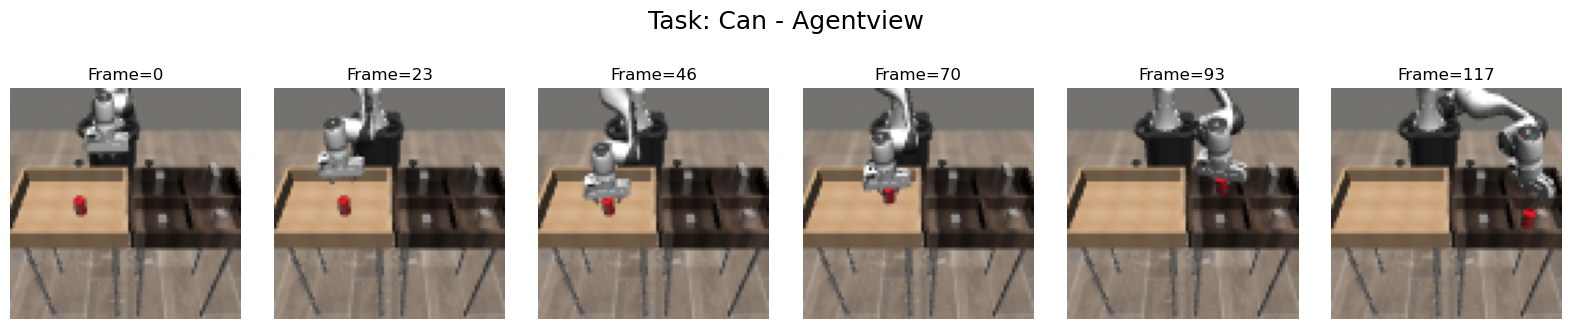

In [13]:
import h5py
import matplotlib.pyplot as plt

with h5py.File("/home/benjamin/Masteroppgave/robomimic_Even_og_Benjamin/datasets/can/ph/image_can.hdf5", "r") as f:
    demos = list(f["data"].keys())
    frames = f[f"data/{demos[0]}/obs/agentview_image"][:]  # shape (T, 84, 84, 3)

# plot a few frames across the trajectory
num_frames = 6
indices = [int(i * (len(frames) - 1) / (num_frames - 1)) for i in range(num_frames)]

fig, axes = plt.subplots(1, num_frames, figsize=(16, 3))
for ax, idx in zip(axes, indices):
    ax.imshow(frames[idx])
    ax.set_title(f"Frame={idx}")
    ax.axis("off")
plt.suptitle(f"Task: Can - Agentview", fontsize=18, y=1.08)
plt.tight_layout()
plt.show()


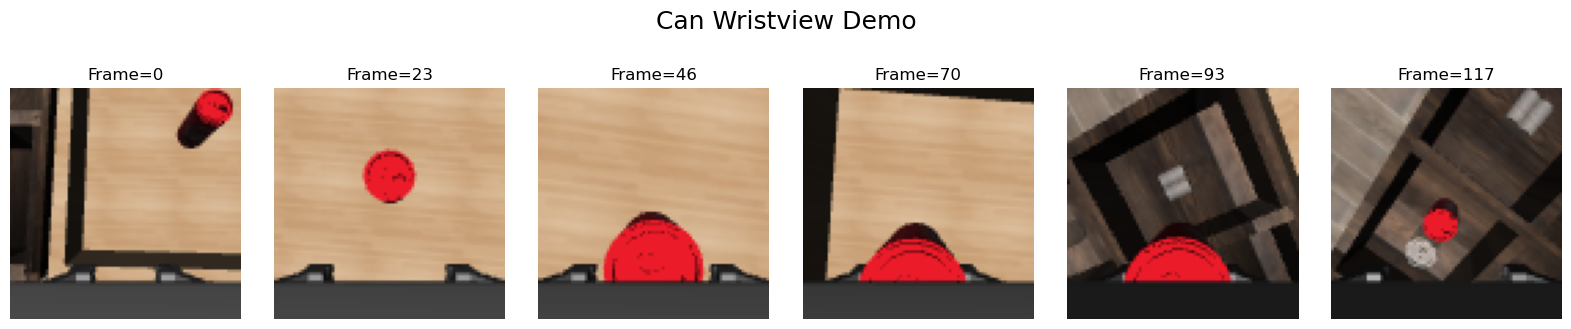

In [ ]:
with h5py.File("/home/benjamin/Masteroppgave/robomimic_Even_og_Benjamin/datasets/can/ph/image_can.hdf5", "r") as f:
    demos = list(f["data"].keys())
    frames = f[f"data/{demos[0]}/obs/robot0_eye_in_hand_image"][:]  # shape (T, 84, 84, 3)

# plot a few frames across the trajectory
num_frames = 6
indices = [int(i * (len(frames) - 1) / (num_frames - 1)) for i in range(num_frames)]

fig, axes = plt.subplots(1, num_frames, figsize=(16, 3))
for ax, idx in zip(axes, indices):
    ax.imshow(frames[idx])
    ax.set_title(f"Frame={idx}")
    ax.axis("off")
plt.suptitle(f"Task: Can - Wristview", fontsize=18, y=1.08)
plt.tight_layout()
plt.show()


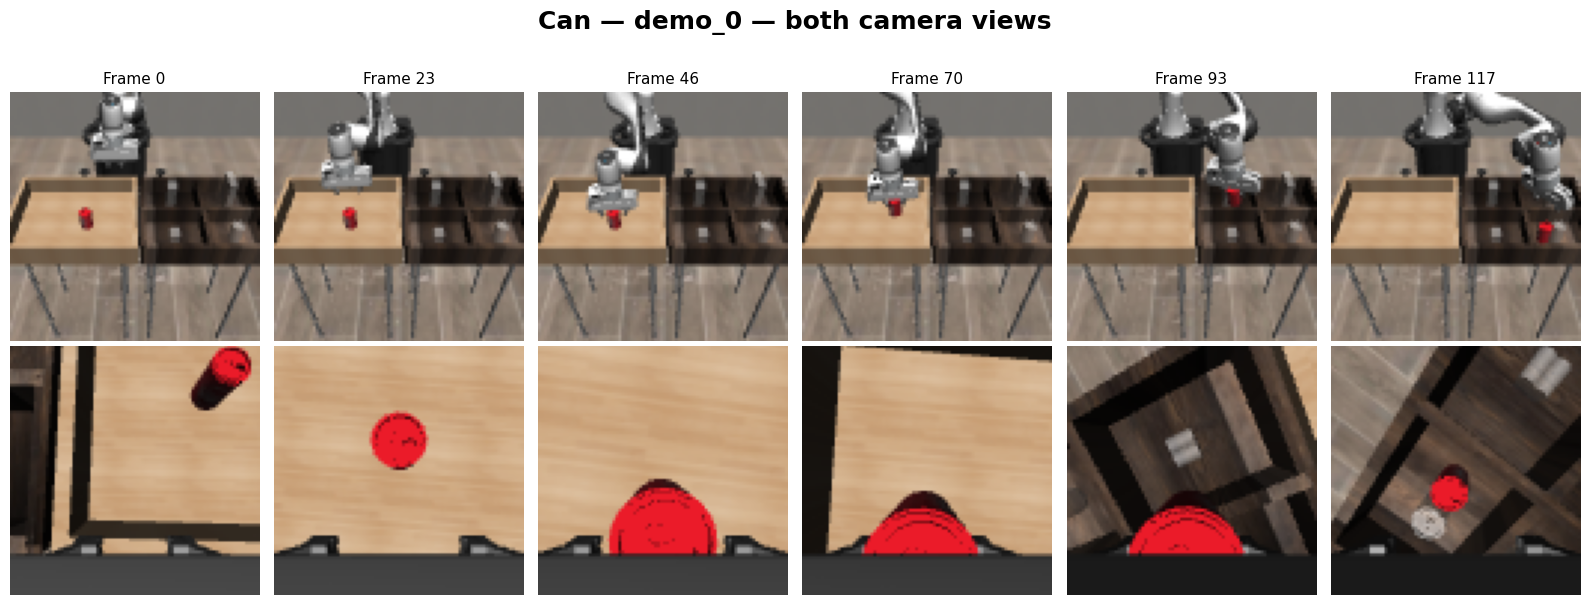

In [9]:
with h5py.File("/home/benjamin/Masteroppgave/robomimic_Even_og_Benjamin/datasets/can/ph/image_can.hdf5", "r") as f:
    demos = list(f["data"].keys())
    demo = demos[0]
    agent_frames = f[f"data/{demo}/obs/agentview_image"][:]
    hand_frames  = f[f"data/{demo}/obs/robot0_eye_in_hand_image"][:]

num_frames = 6
T = len(agent_frames)
indices = [int(i * (T - 1) / (num_frames - 1)) for i in range(num_frames)]

row_labels = ["Agent view", "Eye-in-hand"]
all_frames = [agent_frames, hand_frames]

fig, axes = plt.subplots(2, num_frames, figsize=(16, 6))
fig.suptitle(f"Can — {demo} — both camera views", fontsize=18, fontweight="bold", y=1.02)

for row, (label, frames) in enumerate(zip(row_labels, all_frames)):
    for col, idx in enumerate(indices):
        ax = axes[row, col]
        ax.imshow(frames[idx])
        ax.axis("off")
        if row == 0:
            ax.set_title(f"Frame {idx}", fontsize=11)
    axes[row, 0].set_ylabel(label, fontsize=13, fontweight="bold", labelpad=10)
    axes[row, 0].axis("off")

plt.tight_layout()
plt.show()
